In [26]:
# avoid printing all logs which show paths, comment out to see warnings.
import warnings
warnings.filterwarnings("ignore") 

In [18]:
import sys

!{sys.executable} -m pip install --upgrade -q tcia-utils

In [19]:
from tcia_utils import nbia
import pandas as pd
import requests
import os

Using example data as in [TCIA_Notebooks](https://github.com/kirbyju/TCIA_Notebooks/blob/main/TCIA_Image_Visualization_with_itkWidgets.ipynb) 

In [20]:
cartName = "nbia-77761668716072016"

# retrieve cart metadata
cart_data = nbia.getSharedCart(cartName)

# download the series_uids list and return dataframe of metadata
df = nbia.downloadSeries(cart_data, format = "df")

# display dataframe
display(df)

2025-07-10 18:18:43,769:INFO:Calling getContentsByName with parameters {'name': 'nbia-77761668716072016'}
2025-07-10 18:18:44,834:INFO:Downloading 2 out of 2 Series Instance UIDs (scans).
2025-07-10 18:18:44,835:INFO:Directory 'tciaDownload' already exists.
2025-07-10 18:18:44,836:WARNING:Series 1.3.6.1.4.1.14519.5.2.1.144673070302354240405004153445986965004 already downloaded and unzipped.
2025-07-10 18:18:45,952:WARNING:Series 1.3.6.1.4.1.14519.5.2.1.66734119033932110513438442707181367414 already downloaded and unzipped.
2025-07-10 18:18:46,986:INFO:Downloaded 0 out of 2 Series Instance UIDs (scans).
0 failed to download.
2 previously downloaded.


,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,...,License Name,License URL,Annotation Size,Date Released,Annotations Flag,Manufacturer Model Name,Software Versions,TimeStamp,Series Date,Body Part Examined
0,1.3.6.1.4.1.14519.5.2.1.1446730703023542404050...,Pediatric-CT-SEG,NO,https://doi.org/10.7937/tcia.x0h0-1706,Pediatric-CT-SEG-00DCF4D6,1.3.6.1.4.1.14519.5.2.1.8859670961354389003042...,CT,10-09-2009,RTSTRUCT,Varian Medical Systems,...,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,0,Mon Nov 22 13:02:38 UTC 2021,false,ARIA RTM,4.2.7.0,Mon Nov 22 13:02:38 UTC 2021,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.6673411903393211051343...,Pediatric-CT-SEG,NO,https://doi.org/10.7937/tcia.x0h0-1706,Pediatric-CT-SEG-00DCF4D6,1.3.6.1.4.1.14519.5.2.1.8859670961354389003042...,CT,10-09-2009,CT,GE MEDICAL SYSTEMS,...,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,0,Mon Nov 22 14:20:32 UTC 2021,false,Revolution CT,revo_ct_21a.33,Mon Nov 22 14:20:32 UTC 2021,Fri Oct 09 00:00:00 UTC 2009,ABDOMEN


In [21]:
dicom_data_dir = "tciaDownload/"
ct_series_uid = df.at[df.Modality.eq('CT').idxmax(), 'Series UID']
dicom_ct_dir = os.path.join(dicom_data_dir, ct_series_uid)

In [22]:
from medical_viewer_matplot import MedicalImageReader, MedicalViewerMatplot
import os
%matplotlib widget

In [23]:
modality = "CT"
image_reader = MedicalImageReader(image_path=dicom_ct_dir, modality=modality)

Modality: CT
Image tciaDownload/1.3.6.1.4.1.14519.5.2.1.66734119033932110513438442707181367414 read


In [24]:
medical_viewer = MedicalViewerMatplot(image_reader)

=== IMAGE INFORMATION ===
Array shape (depth, height, width): (207, 512, 512)
Pixel spacing (x, y, z): (0.585938, 0.585938, 2.0)
View indices (which axis for each view): {'axial': np.int64(2), 'coronal': np.int64(1), 'sagittal': np.int64(0)}
View transforms (orientation corrections): {'axial': {'transpose': False, 'flip_x': np.False_, 'flip_y': np.True_, 'x_axis': 0, 'y_axis': 1}, 'coronal': {'transpose': False, 'flip_x': np.False_, 'flip_y': np.False_, 'x_axis': 0, 'y_axis': 2}, 'sagittal': {'transpose': False, 'flip_x': np.False_, 'flip_y': np.False_, 'x_axis': 1, 'y_axis': 2}}
axial view: using dimension 2, max slices: 206, starting at slice: 103
sagittal view: using dimension 0, max slices: 511, starting at slice: 255
coronal view: using dimension 1, max slices: 511, starting at slice: 255
Setting initial crosshairs at center: (256, 256, 103)


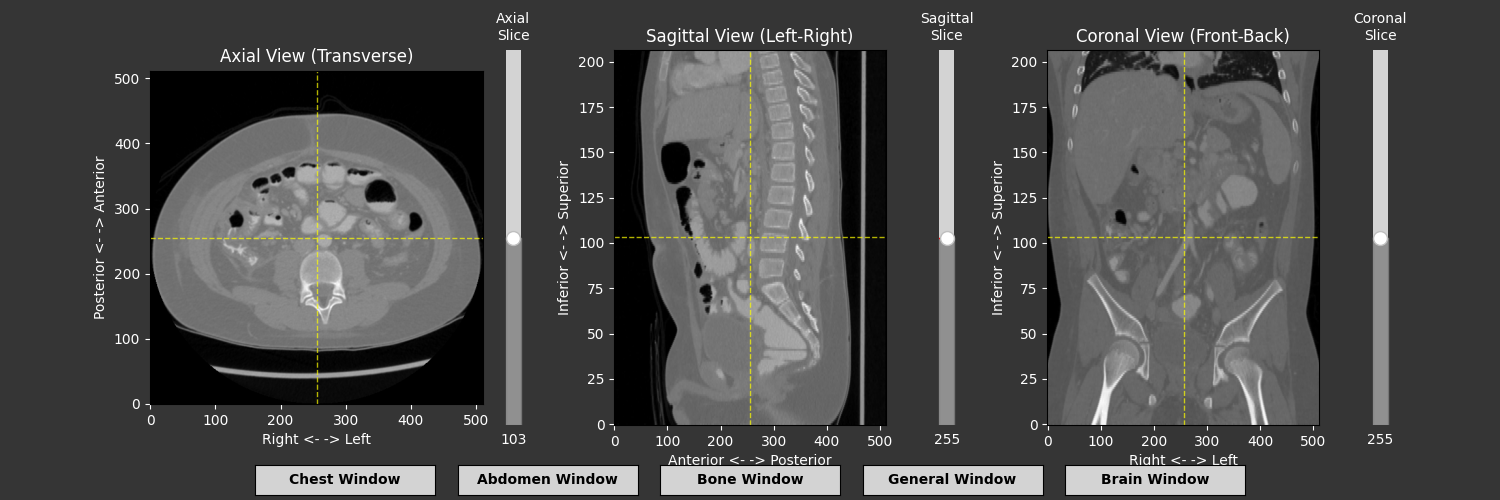

In [25]:
# Create the interactive viewer
medical_viewer = MedicalViewerMatplot(image_reader)

# Start the interactive viewer
medical_viewer.view_dicom_series()